### Libraries.

In [1]:
import math
import os
import os
import sys
from typing import Literal, OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
# import scvi
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm

from sc_exp_design.constants import DataFields
from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching
from sc_exp_design.utils import set_reproducibility

sys.path.insert(0, "../../scripts")
from fetch_data import get_log_transformed_experimental_variables
from data_utils import (
    get_one_hot_encoded_protocols,
    get_one_hot_encoded_protocol_axis
)


### Constants.

In [2]:
# working locally?
IS_RUN_LOCALLY = False

# paths
if IS_RUN_LOCALLY:
    H5AD_PATH = "/Users/lorenzo.consoli/Work/data/collab-goettgens/ds_HID01_logicle_100k_UMAP_ann.h5ad"
else:
    H5AD_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"

# obs columns
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]',
    'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]',
    'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]'
]
SCATTER_COLUMNS = [
    'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width'
]
LOG1P_EXP_COL = [
    "um171_[nm]", "um729_[µm]", "scf_[ng_ml]", 
    "butyzamide_[nm]", "o2_[%]",
    "sr1_[nm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]"
]
LOG21P_EXP_COL = [
    "ldl_[ng_ml]", "il3_[ng_ml]", "retinoic_acid_[µm]",
]

# adata keys
X_CHANNEL_OBSM_KEY = "X_channel"
X_SCATTER_OBSM_KEY = "X_scatter"
OHE_PROTOCOLS_OBS_KEY = "protocol"
OHE_PROTOCOLS_UNS_KEY = "protocol_ohe"
CONCAT_FEATS_OBSM_KEY_SUFFIX = "scatter_concat"
STANDARDIZED_FEATS_KEY_SUFFIX = "standardized"
CONDITION_CONCAT_OBSM_KEY = "protocol_axes_concat"

# training
TRAIN_BATCH_SIZE = 256
VAL_BATCH_SIZE = 64
LR = 1e-3
NUM_GRAD_STEPS = 100_000
GRAD_STEPS_LOG_INTERVAL = 10
NUM_GRAD_ACCUMULATIONS_STEPS=1

# model
FLOW_TYPE = "rectified"
COUPLING_TYPE = "independent"
GENERATE_FROM_NOISE = True

# vf
ENCODE_STATE = True
ENCODE_TIME = True
USE_SINUSOIDAL_TIME_FEATURES = True
ENCODE_CONDITIONS = True

STATE_LATENT_DIM = 16
TIME_LATENT_DIM = 4
CONDITION_LATENT_DIM = 4

STATE_ENCODER_HIDDEN_DIMS = (128, 128)
VF_DECODER_HIDDEN_DIMS = (128, 128)
CONDITION_ENCODER_HIDDEN_DIMS = (64, 64)
TIME_ENCODER_HIDDEN_DIMS = (64, 64)

DEVICE = "cuda"

# sampling
N_SAMPLES = 5_000

# reproducibility
SEED = 42
set_reproducibility(SEED)


### Reading data.

In [3]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Annotating conditions.

In [4]:
# concatenated experimental variable
adata = get_log_transformed_experimental_variables(
    adata,
    EXPERIMENTAL_COLUMNS,
    LOG1P_EXP_COL,
    LOG21P_EXP_COL,
    CONDITION_CONCAT_OBSM_KEY
)

# one hot encoding of concatenated protocol axes
adata = get_one_hot_encoded_protocols(
    adata,
    EXPERIMENTAL_COLUMNS,
    OHE_PROTOCOLS_OBS_KEY,
    OHE_PROTOCOLS_UNS_KEY
)


# one hot encoding of concatenated protocol axes
adata = get_one_hot_encoded_protocol_axis(
    adata,
    EXPERIMENTAL_COLUMNS,
    OHE_PROTOCOLS_UNS_KEY
)
adata


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'protocol_ohe', 'mtg_[µm]_protocol_ohe', 'rhflt3l_

### Splitting data.

In [5]:
train_adata, val_adata = train_test_split(adata, test_size=0.3)
train_adata.shape, val_adata.shape

((70000, 21), (30000, 21))

### Tranforming scatter data.

In [6]:
# retrieving scatter features and optionally normalizing them
X_scatter_train = train_adata.obs[SCATTER_COLUMNS].values
X_scatter_val =  val_adata.obs[SCATTER_COLUMNS].values
X_scatter_mean = X_scatter_train.mean(0)
X_scatter_std = X_scatter_train.std(0)
print("Standardizing scatter features")
X_scatter_train_std = (X_scatter_train - X_scatter_mean)/X_scatter_std
X_scatter_val_std = (X_scatter_val - X_scatter_mean)/X_scatter_std
assert np.isfinite(X_scatter_train_std).all()
assert np.isfinite(X_scatter_val_std).all()
train_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_train
val_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_val
train_adata.obsm[f"{X_SCATTER_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}"] = X_scatter_train_std
val_adata.obsm[f"{X_SCATTER_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}"] = X_scatter_val_std


Standardizing scatter features


/tmp/ipykernel_2347444/2104843479.py:11: ImplicitModificationWarning: Setting element `.obsm['X_scatter']` of view, initializing view as actual.
  train_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_train
/tmp/ipykernel_2347444/2104843479.py:12: ImplicitModificationWarning: Setting element `.obsm['X_scatter']` of view, initializing view as actual.
  val_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_val


### Tranforming channel data and concatenating it with scatter features.

In [7]:
# concatenating with channel features
train_adata.obsm[X_CHANNEL_OBSM_KEY] = train_adata.X
val_adata.obsm[X_CHANNEL_OBSM_KEY] = val_adata.X
X_channel_train = train_adata.X
X_channel_val = val_adata.X
X_channel_mean = X_channel_train.mean(0)
X_channel_std = X_channel_train.std(0)
print("Standardizing channel features")
X_channel_train_std = (X_channel_train - X_channel_mean)/X_channel_std
X_channel_val_std = (X_channel_val - X_channel_mean)/X_channel_std
assert np.isfinite(X_channel_train).all()
assert np.isfinite(X_channel_val).all()
train_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}"] = X_channel_train_std
val_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}"] = X_channel_val_std
train_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_train_std, X_scatter_train_std), axis=1)
val_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_val_std, X_scatter_val_std), axis=1)
train_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_train, X_scatter_train), axis=1)
val_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_val, X_scatter_val), axis=1)
train_adata, val_adata

Standardizing channel features


(AnnData object with n_obs × n_vars = 70000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'protocol_ohe', 'mtg_[µm]_protocol_ohe', 'rhflt

### Predefining mlp settings.

In [8]:
get_mlp_config = lambda hidden_dims, final_activation_class=torch.nn.Identity: {
    "hidden_dims": hidden_dims,
    "use_batchnorm": False,
    "use_dropout": False,
    "activation_class": torch.nn.ReLU,
    "final_activation_class": final_activation_class,
}
get_lm_config = lambda final_activation_class=torch.nn.Identity: get_mlp_config((), final_activation_class=final_activation_class)


### Predefining nn settings.

In [9]:
get_cond_encoder_concat = lambda hidden_dims=CONDITION_ENCODER_HIDDEN_DIMS: {
    "perturbation_layers_before_pooling":{
        f"feats_{CONDITION_CONCAT_OBSM_KEY}_{CONDITION_CONCAT_OBSM_KEY}": 
        {
            "input_dim": adata.obsm[CONDITION_CONCAT_OBSM_KEY].shape[-1],
            "output_dim": CONDITION_LATENT_DIM,
            **get_mlp_config(
                hidden_dims
            )
        }
    },
    "perturbation_layers_after_pooling": get_lm_config()
}
get_cond_encoder_ohe = lambda hidden_dims=CONDITION_ENCODER_HIDDEN_DIMS: {
    "perturbation_layers_before_pooling":{
        f"repr_{OHE_PROTOCOLS_OBS_KEY}_{OHE_PROTOCOLS_UNS_KEY}": {
            "input_dim": list(adata.uns[OHE_PROTOCOLS_UNS_KEY].values())[0].shape[-1],
            "output_dim": CONDITION_LATENT_DIM,
            **get_mlp_config(hidden_dims)
        }
    },
    "perturbation_layers_after_pooling": get_lm_config()
}
get_cond_encoder_ohe_axis = lambda hidden_dims=CONDITION_ENCODER_HIDDEN_DIMS: {
    "perturbation_layers_before_pooling":{
        f"repr_{protocol_axis}_{protocol_axis}_{protocol_axis}_{OHE_PROTOCOLS_UNS_KEY}":  {
            "input_dim": list(adata.uns[f"{protocol_axis}_{OHE_PROTOCOLS_UNS_KEY}"].values())[0].shape[-1],
            "output_dim": CONDITION_LATENT_DIM,
            **get_mlp_config(hidden_dims)
        }
        for protocol_axis in EXPERIMENTAL_COLUMNS
    },
    "perturbation_layers_after_pooling": get_lm_config()
}

### Defining data settings.

In [10]:
# defining dictionary for each conditioning mode settings
conditioning_mode_data_setting_dict = {
    #"unconditional": {}, 
    "protocol_concat": {
        "perturbations": (CONDITION_CONCAT_OBSM_KEY),
        "perturbations_in_obsm": (CONDITION_CONCAT_OBSM_KEY),
        "perturbation_reps": {CONDITION_CONCAT_OBSM_KEY: CONDITION_CONCAT_OBSM_KEY},
    },
    #"protocol_ohe": {
    #    "perturbations": (OHE_PROTOCOLS_OBS_KEY, ),
    #    "perturbation_reps": {OHE_PROTOCOLS_OBS_KEY: OHE_PROTOCOLS_UNS_KEY}
    #},
    #"protocol_axes_ohe": {
    #    "perturbations": EXPERIMENTAL_COLUMNS,
    #    "perturbation_reps": {protocol_ax: f"{protocol_ax}_{OHE_PROTOCOLS_UNS_KEY}" for protocol_ax in EXPERIMENTAL_COLUMNS}
    #}
}
conditioning_mode_setting_dict = {
    # "unconditional": lambda: {},
    "protocol_concat": get_cond_encoder_concat,
    #"protocol_ohe": get_cond_encoder_ohe,
    #"protocol_axes_ohe": get_cond_encoder_ohe_axis,
}

#reprs = [X_CHANNEL_OBSM_KEY, "X_pca", f"X_channel_{CONCAT_FEATS_OBSM_KEY_SUFFIX}", f"X_pca_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"]
# reprs = [X_CHANNEL_OBSM_KEY, f"X_channel_{CONCAT_FEATS_OBSM_KEY_SUFFIX}",]
reprs = ["X_channel_standardized_scatter_concat", ]

# initializing data managers
counter = 0
model_dict = {}
for repr in reprs:
    for conditioning_mode, conditioning_settings in conditioning_mode_data_setting_dict.items():
        # info message
        model_id = f"{repr}_{conditioning_mode}"
        print(f"Fitting model {model_id} ({counter}/{len(conditioning_mode_data_setting_dict)*len(reprs)})")
        if model_id in model_dict:
            continue
        #if ("channel" not in model_id) or ("protocol_concat" not in model_id):
        #    continue

        # initializing model and preparing data
        model = FlowMatching(
            flow_type=FLOW_TYPE,
            coupling_type=COUPLING_TYPE,
            generate_from_noise=GENERATE_FROM_NOISE,
            device_id=DEVICE,
        )
        print(f"Preparing data")
        model.prepare_train_data(
            train_adata,
            repr,
            **conditioning_settings
        )

        # initializing config velocity field
        cond_settings = conditioning_mode_setting_dict[conditioning_mode]()
        optimizer_class = torch.optim.Adam

        vf_config = NeuralVelocityFieldConfig(
            model.train_data.state_data.shape[-1],
            encode_state=ENCODE_STATE,
            state_encoder_output_dim=STATE_LATENT_DIM,
            state_encoder_mlp_kwargs=get_mlp_config(STATE_ENCODER_HIDDEN_DIMS),
            encode_time=ENCODE_TIME,
            use_sinusoidal_time_features=USE_SINUSOIDAL_TIME_FEATURES,
            time_encoder_output_dim=TIME_LATENT_DIM,
            time_encoder_mlp_kwargs=get_mlp_config(TIME_ENCODER_HIDDEN_DIMS),
            use_guidance=len(conditioning_settings) > 0,
            encode_conditions=ENCODE_CONDITIONS,
            perturbation_encoder_output_dim=CONDITION_LATENT_DIM,
            perturbation_layers_before_pooling=cond_settings.get("perturbation_layers_before_pooling", None),
            perturbation_layers_after_pooling=cond_settings.get("perturbation_layers_after_pooling", None),
            decoder_mlp_kwargs=get_mlp_config(VF_DECODER_HIDDEN_DIMS),
        )
        print(f"Preparing model")
        model.prepare_model(
            vf_config,
            optimizer_class=optimizer_class,
            optimizer_kwargs={"lr": LR}
        )

        model.train(
            num_training_steps=NUM_GRAD_STEPS,
            train_batch_size=TRAIN_BATCH_SIZE,
            grad_steps_log_interval=GRAD_STEPS_LOG_INTERVAL,
            num_grad_accumulation_steps=NUM_GRAD_ACCUMULATIONS_STEPS,
        )
        model_dict[model_id] = model
        counter += 1

Fitting model X_channel_standardized_scatter_concat_protocol_concat (0/1)
Preparing data
Preparing model


/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/torch/_compile.py:32: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)
Loss: 1.2087: 100%|██████████| 100000/100000 [08:01<00:00, 207.89it/s]


### Visualizing distributions of features.

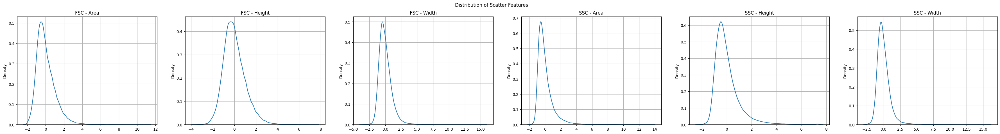

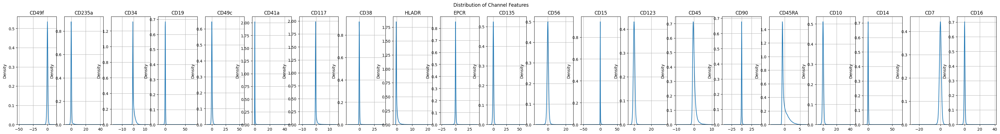

In [11]:
data = X_scatter_train_std
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("Distribution of Scatter Features")
for idx in range(data.shape[1]):
    # antibody = int2antibody[idx]
    sns.kdeplot(data[:, idx], ax=axes[idx])
    axes[idx].grid(True)
    axes[idx].set_title(SCATTER_COLUMNS[idx])

data = X_channel_train_std
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("Distribution of Channel Features")
for idx in range(data.shape[1]):
    # antibody = int2antibody[idx]
    sns.kdeplot(data[:, idx], ax=axes[idx])
    axes[idx].grid(True)
    axes[idx].set_title(adata.var_names[idx])


### Running predictions with the model.


In [12]:
X_hat = model.predict(
    {
       DataFields.PERTURBATION_DATA: {
           model.train_data.data.perturbation_covariates[0]: torch.from_numpy(val_adata.obsm[CONDITION_CONCAT_OBSM_KEY]).float().to(model.device)
       }
    }
).detach().cpu().numpy()
X_channel_hat = X_hat[:, :-len(SCATTER_COLUMNS)]
X_scatter_hat = X_hat[:, -len(SCATTER_COLUMNS):]

### Visualizing KDE of predictions.

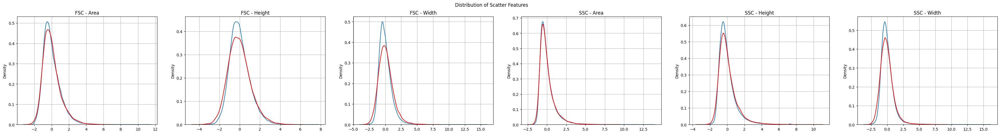

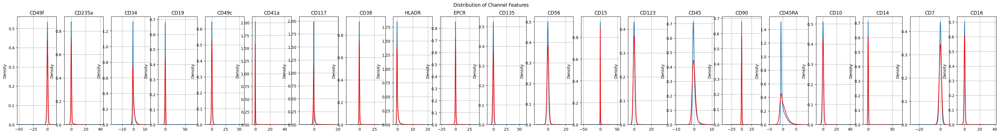

In [13]:
data = X_scatter_train_std
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("Distribution of Scatter Features")
for idx in range(data.shape[1]):
    # antibody = int2antibody[idx]
    sns.kdeplot(data[:, idx], ax=axes[idx])
    sns.kdeplot(X_scatter_hat[:, idx], ax=axes[idx], color="red")
    axes[idx].grid(True)
    axes[idx].set_title(SCATTER_COLUMNS[idx])

data = X_channel_train_std
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("Distribution of Channel Features")
for idx in range(data.shape[1]):
    # antibody = int2antibody[idx]
    sns.kdeplot(data[:, idx], ax=axes[idx])
    sns.kdeplot(X_channel_hat[:, idx], ax=axes[idx], color="red")
    axes[idx].grid(True)
    axes[idx].set_title(adata.var_names[idx])


### Predicting for each protocol.

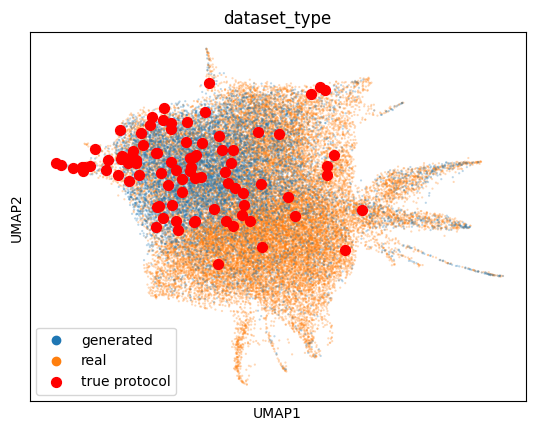

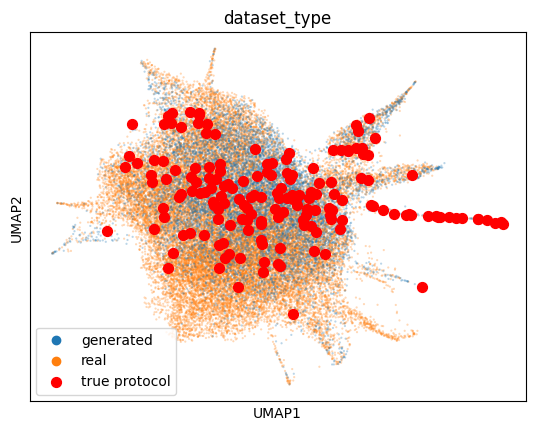

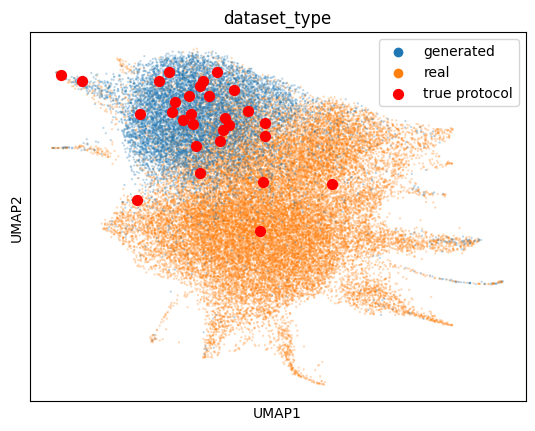

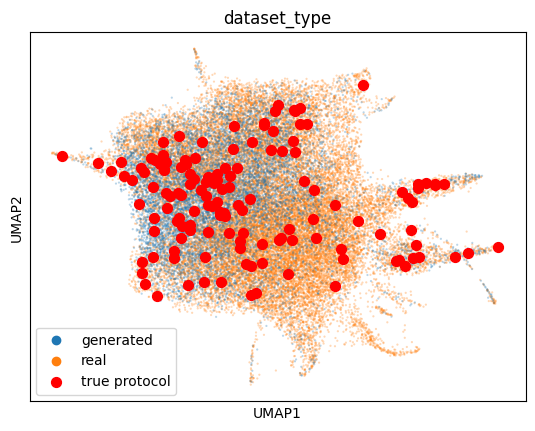

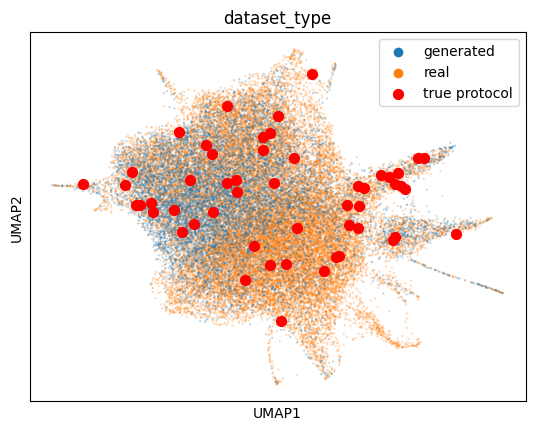

...

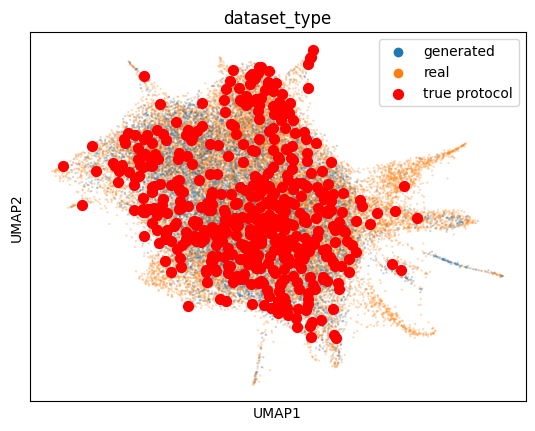

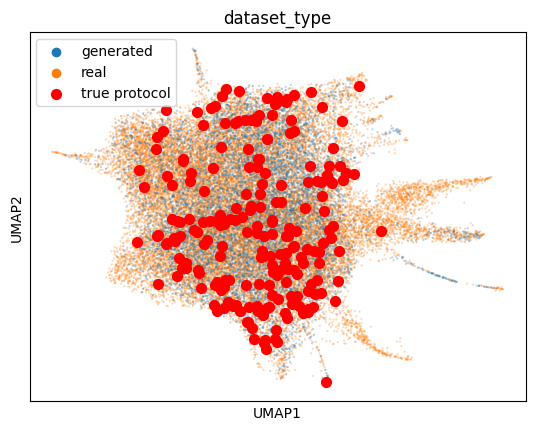

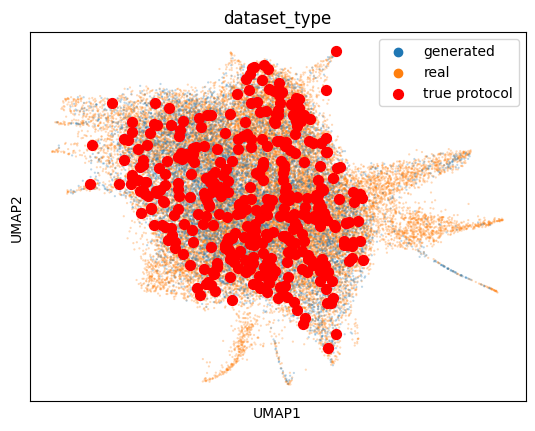

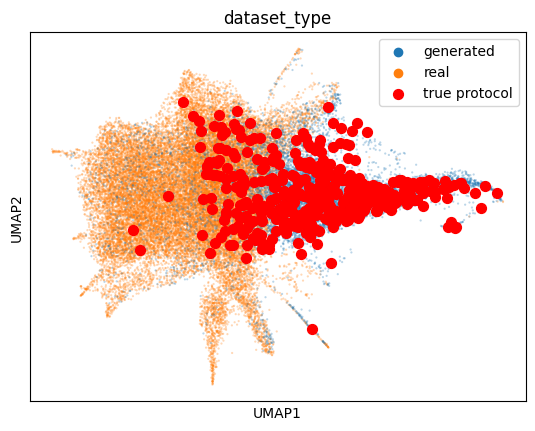

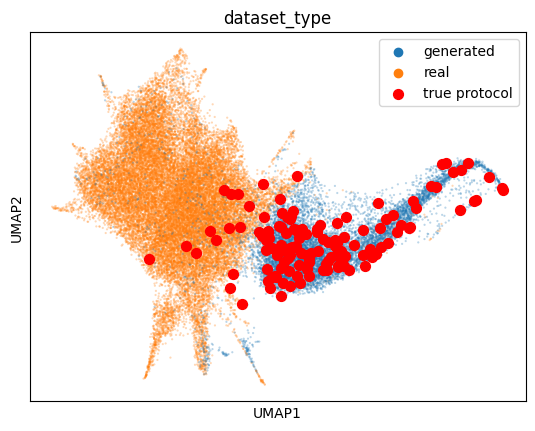

In [40]:
adata_preds = {}
n_samples = 10_000
for idx, val in enumerate(np.unique(val_adata.obsm[CONDITION_CONCAT_OBSM_KEY], axis=0)):
    # break
    val = val[None]
    X_hat = model.predict(
        {
            DataFields.PERTURBATION_DATA: {
                model.train_data.data.perturbation_covariates[0]: torch.from_numpy(val).float().to(model.device)
            }
        },
        num_samples=n_samples
    ).squeeze().detach().cpu().numpy()
    X_channel_hat = X_hat[:, :-len(SCATTER_COLUMNS)]
    X_scatter_hat = X_hat[:, -len(SCATTER_COLUMNS):]
    X_channel_gen_concat = np.concatenate((X_channel_val_std, X_channel_hat), axis=0)
    X_scatter_gen_concat = np.concatenate((X_scatter_val_std, X_scatter_hat), axis=0)
    adata_gen = sc.AnnData(
        X=X_channel_gen_concat,
        obsm={"X_scatter": X_scatter_gen_concat},
        obs={
            "protocol_id": (val_adata.obsm[CONDITION_CONCAT_OBSM_KEY] == val).all(axis=1).tolist() + [True for _ in range(n_samples)],
            "dataset_type": ["real" for _ in range(len(val_adata))] + ["generated" for _ in range(n_samples)]
        }
    )
    adata_gen.obs["is_true_protocol"] = adata_gen.obs["protocol_id"]*(adata_gen.obs["dataset_type"]=="real")
    sc.pp.pca(adata_gen)
    sc.pp.neighbors(adata_gen)
    sc.tl.umap(adata_gen)
    adata_preds[idx] = adata_gen
    # sc.pl.umap(adata_gen, color=adata_gen.obs_keys())
    import matplotlib.pyplot as plt

    sc.pl.umap(
        adata_gen,
        color="dataset_type",
        size=10,  # small dots for all cells
        alpha=0.3,
        show=False
    )

    # Overlay "is_true_protocol" points with a bigger size
    true_mask = adata_gen.obs["is_true_protocol"].astype(bool).values
    umap = adata_gen.obsm["X_umap"]

    plt.scatter(
        umap[true_mask, 0],
        umap[true_mask, 1],
        c="red",
        s=50,       # magnified size
        label="true protocol"
    )

    plt.legend()
    plt.show()

